# Notebook 07 — Product & Category Intelligence

## Product & Growth Intelligence Platform

### Objective

Connect observed user events to products and categories to identify where product interest, funnel progression, and behavioral segments intersect.

### Business question

> **Which products and categories attract attention, generate cart activity, and convert — and where is there a measurable gap between interest and purchase progression?**

### What this notebook does

- Builds an item → category mapping from the RetailRocket item-property files.
- Profiles product-level views, cart activity, and transactions.
- Profiles category-level engagement and funnel participation.
- Identifies high-interest / low-conversion products and categories using transparent evidence thresholds.
- Connects product/category behavior with the finalized visitor segments from Notebook 06.
- Exports reusable CSVs and portfolio-ready figures.

### Important analytical boundary

This notebook measures **observed behavioral activity and event-based progression**. It does not claim revenue, profit, causal conversion drivers, demographics, acquisition source, or randomized experimentation.

In [1]:
# ============================================================
# CELL 1 — PROJECT PATHS & IMPORTS
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = (
    Path.cwd().parent
    if Path.cwd().name.lower() == "notebooks"
    else Path.cwd()
)

DATA_PATH = PROJECT_ROOT / "data" / "raw"
OUTPUTS_PATH = PROJECT_ROOT / "outputs"
FIGURES_PATH = OUTPUTS_PATH / "figures"

OUTPUTS_PATH.mkdir(parents=True, exist_ok=True)
FIGURES_PATH.mkdir(parents=True, exist_ok=True)

EVENTS_PATH = DATA_PATH / "events.csv"
CATEGORY_TREE_PATH = DATA_PATH / "category_tree.csv"
ITEM_PROPERTIES_PATHS = [
    DATA_PATH / "item_properties_part1.csv",
    DATA_PATH / "item_properties_part2.csv",
]

SEGMENT_PATH = OUTPUTS_PATH / "06_visitor_segment_features.csv"

print("PROJECT ROOT:", PROJECT_ROOT)
print("EVENTS FILE EXISTS:", EVENTS_PATH.exists())
print("CATEGORY TREE EXISTS:", CATEGORY_TREE_PATH.exists())
print("ITEM PROPERTY FILES EXIST:", [p.exists() for p in ITEM_PROPERTIES_PATHS])
print("SEGMENT OUTPUT EXISTS:", SEGMENT_PATH.exists())

assert EVENTS_PATH.exists(), f"Missing required file: {EVENTS_PATH}"
assert CATEGORY_TREE_PATH.exists(), f"Missing required file: {CATEGORY_TREE_PATH}"
assert all(p.exists() for p in ITEM_PROPERTIES_PATHS), "One or more item-property files are missing."
assert SEGMENT_PATH.exists(), f"Notebook 06 output is missing: {SEGMENT_PATH}"


PROJECT ROOT: D:\Data science portfolio\03_Product_Growth_Intelligence
EVENTS FILE EXISTS: True
CATEGORY TREE EXISTS: True
ITEM PROPERTY FILES EXIST: [True, True]
SEGMENT OUTPUT EXISTS: True


## 1. Dataset Contract

The locked RetailRocket dataset contains:

- `events.csv`: visitor-level event behavior.
- `category_tree.csv`: category hierarchy.
- `item_properties_part1.csv` and `item_properties_part2.csv`: time-stamped item properties, including `categoryid`.

The raw files are treated as read-only.

Because the item-property files are large, this notebook **does not load all item-property records into memory**. It scans them in chunks and keeps only the `categoryid` property needed for this module.

In [2]:
# ============================================================
# CELL 2 — LOAD EVENT DATA
# ============================================================

EVENT_COLUMNS = [
    "timestamp",
    "visitorid",
    "event",
    "itemid",
    "transactionid",
]

events = pd.read_csv(
    EVENTS_PATH,
    usecols=EVENT_COLUMNS,
)

events["timestamp"] = pd.to_datetime(events["timestamp"], unit="ms", errors="coerce")
events["visitorid"] = pd.to_numeric(events["visitorid"], errors="coerce").astype("Int64")
events["itemid"] = pd.to_numeric(events["itemid"], errors="coerce").astype("Int64")
events["transactionid"] = pd.to_numeric(events["transactionid"], errors="coerce").astype("Int64")

events = events.dropna(subset=["timestamp", "visitorid", "itemid", "event"]).copy()

VALID_EVENTS = {"view", "addtocart", "transaction"}
events = events[events["event"].isin(VALID_EVENTS)].copy()

print("EVENT ROWS:", f"{len(events):,}")
print("UNIQUE VISITORS:", f"{events['visitorid'].nunique():,}")
print("UNIQUE PRODUCTS:", f"{events['itemid'].nunique():,}")
print("EVENT TYPES:")
print(events["event"].value_counts().to_string())

assert len(events) > 0
assert events["visitorid"].notna().all()
assert events["itemid"].notna().all()

EVENT ROWS: 2,756,101
UNIQUE VISITORS: 1,407,580
UNIQUE PRODUCTS: 235,061
EVENT TYPES:
event
view           2664312
addtocart        69332
transaction      22457


In [3]:
# ============================================================
# CELL 3 — LOAD CATEGORY HIERARCHY
# ============================================================

category_tree = pd.read_csv(CATEGORY_TREE_PATH)

required_category_columns = {"categoryid", "parentid"}
missing = required_category_columns - set(category_tree.columns)
assert not missing, f"Missing category-tree columns: {missing}"

category_tree["categoryid"] = pd.to_numeric(
    category_tree["categoryid"], errors="coerce"
).astype("Int64")
category_tree["parentid"] = pd.to_numeric(
    category_tree["parentid"], errors="coerce"
).astype("Int64")

category_tree = category_tree.dropna(subset=["categoryid"]).copy()

print("CATEGORY NODES:", f"{len(category_tree):,}")
print("ROOT CATEGORIES:", f"{category_tree['parentid'].isna().sum():,}")

category_parent = (
    category_tree
    .drop_duplicates("categoryid")
    .set_index("categoryid")["parentid"]
    .to_dict()
)

CATEGORY NODES: 1,669
ROOT CATEGORIES: 25


## 2. Build the Item → Category Mapping

`categoryid` is stored as an item property, so it must be extracted from the large item-property files.

### Processing rule

For each item:

1. Read only `timestamp`, `itemid`, `property`, and `value`.
2. Keep rows where `property == "categoryid"`.
3. Convert the category value to numeric form.
4. If an item has multiple observed category assignments, retain the **latest observed category assignment by timestamp**.

This keeps the processing reproducible while avoiding an unnecessary full-memory load of the item-property dataset.

In [4]:
# ============================================================
# CELL 4 — EXTRACT ITEM → CATEGORY MAPPING EFFICIENTLY
# ============================================================

def extract_item_category_mapping(paths, chunksize=1_000_000):
    category_parts = []

    for path in paths:
        print(f"Scanning: {path.name}")

        for chunk in pd.read_csv(
            path,
            usecols=["timestamp", "itemid", "property", "value"],
            chunksize=chunksize,
        ):
            category_chunk = chunk[
                chunk["property"].eq("categoryid")
            ].copy()

            if category_chunk.empty:
                continue

            category_chunk["timestamp"] = pd.to_datetime(
                category_chunk["timestamp"],
                unit="ms",
                errors="coerce",
            )
            category_chunk["itemid"] = pd.to_numeric(
                category_chunk["itemid"],
                errors="coerce",
            ).astype("Int64")
            category_chunk["categoryid"] = pd.to_numeric(
                category_chunk["value"],
                errors="coerce",
            ).astype("Int64")

            category_chunk = category_chunk.dropna(
                subset=["timestamp", "itemid", "categoryid"]
            )[["timestamp", "itemid", "categoryid"]]

            if not category_chunk.empty:
                category_parts.append(category_chunk)

    if not category_parts:
        raise ValueError("No categoryid item-property records were found.")

    mapping = pd.concat(category_parts, ignore_index=True)

    mapping = (
        mapping
        .sort_values(["itemid", "timestamp"])
        .drop_duplicates("itemid", keep="last")
        [["itemid", "categoryid", "timestamp"]]
        .reset_index(drop=True)
    )

    return mapping


item_category = extract_item_category_mapping(ITEM_PROPERTIES_PATHS)

print("MAPPED PRODUCTS:", f"{item_category['itemid'].nunique():,}")
print("MAPPED CATEGORIES:", f"{item_category['categoryid'].nunique():,}")

assert item_category["itemid"].is_unique
assert item_category["categoryid"].notna().all()

Scanning: item_properties_part1.csv
Scanning: item_properties_part2.csv
MAPPED PRODUCTS: 417,053
MAPPED CATEGORIES: 1,180


In [5]:
# ============================================================
# CELL 5 — ENRICH EVENTS WITH CATEGORY
# ============================================================

events_product = events.merge(
    item_category[["itemid", "categoryid"]],
    on="itemid",
    how="left",
)

events_product["category_label"] = events_product["categoryid"].astype("string")
events_product["category_label"] = events_product["category_label"].fillna(
    "Uncategorized"
)

category_coverage_pct = (
    events_product["categoryid"].notna().mean() * 100
)

product_coverage_pct = (
    events_product.loc[
        events_product["itemid"].isin(item_category["itemid"]),
        "itemid"
    ].nunique()
    / events_product["itemid"].nunique()
    * 100
)

print("EVENT CATEGORY COVERAGE:", f"{category_coverage_pct:.2f}%")
print("PRODUCT CATEGORY COVERAGE:", f"{product_coverage_pct:.2f}%")
print("UNCATEGORIZED EVENT ROWS:", f"{events_product['categoryid'].isna().sum():,}")

EVENT CATEGORY COVERAGE: 90.73%
PRODUCT CATEGORY COVERAGE: 78.81%
UNCATEGORIZED EVENT ROWS: 255,585


## 3. Product Intelligence

Product-level analysis focuses on **observed visitor participation**, not raw event counts alone.

For each product we calculate:

- unique visitors
- viewing visitors
- cart visitors
- transaction visitors
- view events
- cart events
- transaction events
- view → cart participation
- cart → transaction participation
- view → transaction participation

The participation rates use unique visitors at each stage. They should be interpreted as **observed stage participation**, not causal conversion probabilities.

In [6]:
# ============================================================
# CELL 6 — PRODUCT-LEVEL FUNNEL INTELLIGENCE
# ============================================================

def unique_visitors_by_item_event(df, event_name):
    return (
        df.loc[df["event"].eq(event_name)]
        .groupby("itemid")["visitorid"]
        .nunique()
        .rename(f"{event_name}_visitors")
    )

product_counts = (
    events_product.groupby("itemid")
    .agg(
        visitors=("visitorid", "nunique"),
        view_events=("event", lambda s: (s == "view").sum()),
        cart_events=("event", lambda s: (s == "addtocart").sum()),
        transaction_events=("event", lambda s: (s == "transaction").sum()),
    )
)

product_stage_visitors = pd.concat(
    [
        unique_visitors_by_item_event(events_product, "view"),
        unique_visitors_by_item_event(events_product, "addtocart"),
        unique_visitors_by_item_event(events_product, "transaction"),
    ],
    axis=1,
).fillna(0)

product_base = (
    product_counts
    .join(product_stage_visitors)
    .rename(
        columns={
            "view_visitors": "viewed_visitors",
            "addtocart_visitors": "cart_visitors",
            "transaction_visitors": "transaction_visitors",
        }
    )
    .reset_index()
)

product_base["view_to_cart_pct"] = np.where(
    product_base["viewed_visitors"] > 0,
    product_base["cart_visitors"] / product_base["viewed_visitors"] * 100,
    np.nan,
)

product_base["cart_to_transaction_pct"] = np.where(
    product_base["cart_visitors"] > 0,
    product_base["transaction_visitors"]
    / product_base["cart_visitors"] * 100,
    np.nan,
)

product_base["view_to_transaction_pct"] = np.where(
    product_base["viewed_visitors"] > 0,
    product_base["transaction_visitors"]
    / product_base["viewed_visitors"] * 100,
    np.nan,
)

product_base = product_base.merge(
    item_category[["itemid", "categoryid"]],
    on="itemid",
    how="left",
)

print("PRODUCTS PROFILED:", f"{len(product_base):,}")
display(product_base.head())


PRODUCTS PROFILED: 235,061


,itemid,visitors,view_events,cart_events,transaction_events,viewed_visitors,cart_visitors,transaction_visitors,view_to_cart_pct,cart_to_transaction_pct,view_to_transaction_pct,categoryid
0,3,2,2,0,0,2.0,0.0,0.0,0.000000,NaN,0.000000,1171
1,4,3,3,0,0,3.0,0.0,0.0,0.000000,NaN,0.000000,1038
2,6,26,29,0,0,26.0,0.0,0.0,0.000000,NaN,0.000000,1091
3,9,2,2,0,0,2.0,0.0,0.0,0.000000,NaN,0.000000,<NA>
4,15,13,18,3,1,13.0,2.0,1.0,15.384615,50.0,7.692308,722


In [7]:
# ============================================================
# CELL 7 — CATEGORY-LEVEL FUNNEL INTELLIGENCE
# ============================================================

def unique_visitors_by_category_event(df, event_name):
    return (
        df.loc[df["event"].eq(event_name)]
        .groupby("category_label")["visitorid"]
        .nunique()
        .rename(f"{event_name}_visitors")
    )

category_counts = (
    events_product.groupby("category_label")
    .agg(
        visitors=("visitorid", "nunique"),
        view_events=("event", lambda s: (s == "view").sum()),
        cart_events=("event", lambda s: (s == "addtocart").sum()),
        transaction_events=("event", lambda s: (s == "transaction").sum()),
        unique_products=("itemid", "nunique"),
    )
)

category_stage_visitors = pd.concat(
    [
        unique_visitors_by_category_event(events_product, "view"),
        unique_visitors_by_category_event(events_product, "addtocart"),
        unique_visitors_by_category_event(events_product, "transaction"),
    ],
    axis=1,
).fillna(0)

category_base = (
    category_counts
    .join(category_stage_visitors)
    .rename(
        columns={
            "view_visitors": "viewed_visitors",
            "addtocart_visitors": "cart_visitors",
            "transaction_visitors": "transaction_visitors",
        }
    )
    .reset_index()
    .rename(columns={"category_label": "category"})
)

category_base["view_to_cart_pct"] = np.where(
    category_base["viewed_visitors"] > 0,
    category_base["cart_visitors"]
    / category_base["viewed_visitors"] * 100,
    np.nan,
)

category_base["cart_to_transaction_pct"] = np.where(
    category_base["cart_visitors"] > 0,
    category_base["transaction_visitors"]
    / category_base["cart_visitors"] * 100,
    np.nan,
)

category_base["view_to_transaction_pct"] = np.where(
    category_base["viewed_visitors"] > 0,
    category_base["transaction_visitors"]
    / category_base["viewed_visitors"] * 100,
    np.nan,
)

print("CATEGORIES PROFILED:", f"{len(category_base):,}")
display(category_base.head())


CATEGORIES PROFILED: 1,087


,category,visitors,view_events,cart_events,transaction_events,unique_products,viewed_visitors,cart_visitors,transaction_visitors,view_to_cart_pct,cart_to_transaction_pct,view_to_transaction_pct
0,0,814,1049,59,12,95,803,44.0,12.0,5.479452,27.272727,1.494396
1,1,3757,5847,392,80,641,3747,197.0,55.0,5.257539,27.918782,1.467841
2,10,2,2,0,0,1,2,0.0,0.0,0.000000,NaN,0.000000
3,100,14,18,0,0,6,14,0.0,0.0,0.000000,NaN,0.000000
4,1000,24,27,0,0,2,24,0.0,0.0,0.000000,NaN,0.000000


In [8]:
# ============================================================
# CELL 8 — PORTFOLIO-SAFE PARTICIPATION METRICS
# ============================================================

# These rates intentionally use total observed visitors as the denominator.
# This guarantees bounded 0–100% participation measures even when the
# dataset does not capture every intermediate event for the same visitor.

for frame in [product_base, category_base]:
    frame["view_participation_pct"] = np.where(
        frame["visitors"] > 0,
        frame["viewed_visitors"] / frame["visitors"] * 100,
        np.nan,
    )
    frame["cart_participation_pct"] = np.where(
        frame["visitors"] > 0,
        frame["cart_visitors"] / frame["visitors"] * 100,
        np.nan,
    )
    frame["transaction_participation_pct"] = np.where(
        frame["visitors"] > 0,
        frame["transaction_visitors"] / frame["visitors"] * 100,
        np.nan,
    )

print("Participation metrics recalculated using total observed visitors.")
print("Product transaction participation range:",
      f"{product_base['transaction_participation_pct'].min():.2f}% → "
      f"{product_base['transaction_participation_pct'].max():.2f}%")
print("Category transaction participation range:",
      f"{category_base['transaction_participation_pct'].min():.2f}% → "
      f"{category_base['transaction_participation_pct'].max():.2f}%")

Participation metrics recalculated using total observed visitors.
Product transaction participation range: 0.00% → 100.00%
Category transaction participation range: 0.00% → 21.43%


## 4. Product & Category Opportunity Detection

The opportunity layer is intentionally **evidence-driven**.

A product/category is considered high-interest only when it has a meaningful observed audience. Among eligible products/categories:

- **High interest** = viewed-visitor count at or above the 90th percentile.
- **Low progression** = view → cart participation below the eligible-population median.
- A minimum viewed-visitor guardrail prevents tiny products/categories from dominating the analysis.

This does not prove why conversion is weak. It identifies a **priority area for investigation**.

In [9]:
# ============================================================
# CELL 9 — HIGH-INTEREST / LOW-PROGRESSION PRODUCTS
# ============================================================

MIN_VIEWERS_PRODUCT = 100

eligible_products = product_base[
    product_base["viewed_visitors"] >= MIN_VIEWERS_PRODUCT
].copy()

product_interest_threshold = (
    eligible_products["viewed_visitors"].quantile(0.90)
)

product_progression_benchmark = (
    eligible_products["view_to_cart_pct"].median()
)

product_opportunities = eligible_products[
    (eligible_products["viewed_visitors"] >= product_interest_threshold)
    & (eligible_products["view_to_cart_pct"] < product_progression_benchmark)
].copy()

product_opportunities["opportunity_signal"] = (
    "High observed product interest with below-median view-to-cart participation"
)

product_opportunities = product_opportunities.sort_values(
    ["viewed_visitors", "view_to_cart_pct"],
    ascending=[False, True],
)

print("PRODUCT INTEREST THRESHOLD:", f"{product_interest_threshold:,.0f} viewed visitors")
print("PRODUCT PROGRESSION BENCHMARK:", f"{product_progression_benchmark:.2f}%")
print("HIGH-INTEREST / LOW-PROGRESSION PRODUCTS:", f"{len(product_opportunities):,}")

display(
    product_opportunities[
        [
            "itemid",
            "categoryid",
            "viewed_visitors",
            "cart_visitors",
            "transaction_visitors",
            "view_to_cart_pct",
            "cart_to_transaction_pct",
        ]
    ].head(20)
)

PRODUCT INTEREST THRESHOLD: 301 viewed visitors
PRODUCT PROGRESSION BENCHMARK: 2.94%
HIGH-INTEREST / LOW-PROGRESSION PRODUCTS: 122


,itemid,categoryid,viewed_visitors,cart_visitors,transaction_visitors,view_to_cart_pct,cart_to_transaction_pct
94720,187946,1393,2911.0,2.0,0.0,0.068705,0.000000
2719,5411,789,2078.0,9.0,0.0,0.433109,0.000000
186716,370653,82,1577.0,0.0,0.0,0.000000,NaN
49024,96924,56,1359.0,0.0,0.0,0.000000,NaN
150148,298009,529,1342.0,0.0,0.0,0.000000,NaN
169261,335975,48,1154.0,0.0,0.0,0.000000,NaN
76432,151444,656,1103.0,0.0,0.0,0.000000,NaN
222448,441668,1263,1078.0,31.0,10.0,2.875696,32.258065
218935,434782,239,938.0,0.0,0.0,0.000000,NaN
71944,142466,1375,936.0,1.0,0.0,0.106838,0.000000


In [10]:
# ============================================================
# CELL 10 — HIGH-INTEREST / LOW-PROGRESSION CATEGORIES
# ============================================================

MIN_VIEWERS_CATEGORY = 500

eligible_categories = category_base[
    category_base["viewed_visitors"] >= MIN_VIEWERS_CATEGORY
].copy()

category_interest_threshold = (
    eligible_categories["viewed_visitors"].quantile(0.90)
)

category_progression_benchmark = (
    eligible_categories["view_to_cart_pct"].median()
)

category_opportunities = eligible_categories[
    (eligible_categories["viewed_visitors"] >= category_interest_threshold)
    & (eligible_categories["view_to_cart_pct"] < category_progression_benchmark)
].copy()

category_opportunities["opportunity_signal"] = (
    "High observed category interest with below-median view-to-cart participation"
)

category_opportunities = category_opportunities.sort_values(
    ["viewed_visitors", "view_to_cart_pct"],
    ascending=[False, True],
)

print("CATEGORY INTEREST THRESHOLD:", f"{category_interest_threshold:,.0f} viewed visitors")
print("CATEGORY PROGRESSION BENCHMARK:", f"{category_progression_benchmark:.2f}%")
print("HIGH-INTEREST / LOW-PROGRESSION CATEGORIES:", f"{len(category_opportunities):,}")

display(category_opportunities.head(20))

CATEGORY INTEREST THRESHOLD: 6,033 viewed visitors
CATEGORY PROGRESSION BENCHMARK: 3.25%
HIGH-INTEREST / LOW-PROGRESSION CATEGORIES: 26


,category,visitors,view_events,cart_events,transaction_events,unique_products,viewed_visitors,cart_visitors,transaction_visitors,view_to_cart_pct,cart_to_transaction_pct,view_to_transaction_pct,view_participation_pct,cart_participation_pct,transaction_participation_pct,opportunity_signal
1086,Uncategorized,197756,254277,833,475,49815,197747,504.0,226.0,0.254871,44.841270,0.114287,99.995449,0.254860,0.114282,High observed category interest with below-med...
352,1483,40778,62786,1525,469,2945,40486,1163.0,341.0,2.872598,29.320722,0.842266,99.283928,2.852028,0.836235,High observed category interest with below-med...
728,491,38029,59300,1551,263,2417,37763,1177.0,222.0,3.116807,18.861512,0.587877,99.300534,3.095006,0.583765,High observed category interest with below-med...
720,48,17124,26705,603,146,1039,17016,473.0,129.0,2.779737,27.272727,0.758110,99.369306,2.762205,0.753329,High observed category interest with below-med...
735,5,15103,28953,577,186,288,15036,440.0,137.0,2.926310,31.136364,0.911147,99.556380,2.913328,0.907105,High observed category interest with below-med...
417,1578,13686,21494,583,105,1065,13650,292.0,84.0,2.139194,28.767123,0.615385,99.736957,2.133567,0.613766,High observed category interest with below-med...
844,646,13537,27669,484,87,1381,13512,349.0,68.0,2.582889,19.484241,0.503256,99.815321,2.578119,0.502327,High observed category interest with below-med...
613,333,12864,22382,416,84,1057,12822,354.0,78.0,2.760880,22.033898,0.608329,99.673507,2.751866,0.606343,High observed category interest with below-med...
155,1221,11472,18248,422,110,1591,11441,277.0,97.0,2.421117,35.018051,0.847828,99.729777,2.414575,0.845537,High observed category interest with below-med...
544,242,11123,16676,489,90,2121,11096,261.0,69.0,2.352199,26.436782,0.621846,99.757260,2.346489,0.620336,High observed category interest with below-med...


## 5. Product Intelligence Rankings

The notebook produces transparent ranking tables for:

1. Most viewed products
2. Most cart-added products
3. Most purchased products
4. Strongest observed view → cart participation among sufficiently viewed products
5. High-interest / low-progression products

The rankings use observable event behavior and avoid calling transaction counts revenue.

In [11]:
# ============================================================
# CELL 11 — PRODUCT RANKINGS
# ============================================================

TOP_N = 20

top_viewed_products = (
    product_base
    .sort_values(["viewed_visitors", "view_events"], ascending=False)
    .head(TOP_N)
    .copy()
)

top_cart_products = (
    product_base
    .sort_values(["cart_visitors", "cart_events"], ascending=False)
    .head(TOP_N)
    .copy()
)

top_purchased_products = (
    product_base
    .sort_values(["transaction_visitors", "transaction_events"], ascending=False)
    .head(TOP_N)
    .copy()
)

strongest_product_progression = (
    eligible_products
    .dropna(subset=["view_to_cart_pct"])
    .sort_values(
        ["view_to_cart_pct", "viewed_visitors"],
        ascending=[False, False],
    )
    .head(TOP_N)
    .copy()
)

print("TOP VIEWED PRODUCTS")
display(top_viewed_products)

print("TOP CART-ACTIVE PRODUCTS")
display(top_cart_products)

print("TOP PURCHASED PRODUCTS")
display(top_purchased_products)

print("STRONGEST OBSERVED VIEW-TO-CART PRODUCTS")
display(strongest_product_progression)

TOP VIEWED PRODUCTS


,itemid,visitors,view_events,cart_events,transaction_events,viewed_visitors,cart_visitors,transaction_visitors,view_to_cart_pct,cart_to_transaction_pct,view_to_transaction_pct,categoryid,view_participation_pct,cart_participation_pct,transaction_participation_pct
94720,187946,2912,3410,2,0,2911.0,2.0,0.0,0.068705,0.000000,0.000000,1393,99.965659,0.068681,0.000000
2719,5411,2079,2325,9,0,2078.0,9.0,0.0,0.433109,0.000000,0.000000,789,99.951900,0.432900,0.000000
186716,370653,1577,1854,0,0,1577.0,0.0,0.0,0.000000,NaN,0.000000,82,100.000000,0.000000,0.000000
232496,461686,1393,2539,306,133,1379.0,267.0,129.0,19.361856,48.314607,9.354605,1037,98.994975,19.167265,9.260589
49024,96924,1359,1633,0,0,1359.0,0.0,0.0,0.000000,NaN,0.000000,56,100.000000,0.000000,0.000000
110536,219512,1370,1740,48,12,1358.0,47.0,12.0,3.460972,25.531915,0.883652,5,99.124088,3.430657,0.875912
150148,298009,1342,1642,0,0,1342.0,0.0,0.0,0.000000,NaN,0.000000,529,100.000000,0.000000,0.000000
169261,335975,1154,1428,0,0,1154.0,0.0,0.0,0.000000,NaN,0.000000,48,100.000000,0.000000,0.000000
193605,384302,1154,1528,65,15,1143.0,55.0,14.0,4.811899,25.454545,1.224847,5,99.046794,4.766031,1.213172
76432,151444,1103,1230,0,0,1103.0,0.0,0.0,0.000000,NaN,0.000000,656,100.000000,0.000000,0.000000


TOP CART-ACTIVE PRODUCTS


,itemid,visitors,view_events,cart_events,transaction_events,viewed_visitors,cart_visitors,transaction_visitors,view_to_cart_pct,cart_to_transaction_pct,view_to_transaction_pct,categoryid,view_participation_pct,cart_participation_pct,transaction_participation_pct
232496,461686,1393,2539,306,133,1379.0,267.0,129.0,19.361856,48.314607,9.354605,1037,98.994975,19.167265,9.260589
161235,320130,886,1333,141,33,846.0,131.0,27.0,15.484634,20.610687,3.191489,1483,95.485327,14.785553,3.047404
157492,312728,615,947,162,46,602.0,129.0,37.0,21.428571,28.682171,6.146179,1098,97.886179,20.975610,6.016260
206467,409804,457,647,156,35,453.0,128.0,30.0,28.256071,23.437500,6.622517,1191,99.124726,28.008753,6.564551
14707,29196,628,912,136,19,624.0,101.0,19.0,16.185897,18.811881,3.044872,1265,99.363057,16.082803,3.025478
3980,7943,846,1346,97,46,843.0,87.0,46.0,10.320285,52.873563,5.456702,398,99.645390,10.283688,5.437352
24339,48030,634,986,95,41,628.0,85.0,38.0,13.535032,44.705882,6.050955,1219,99.053628,13.406940,5.993691
222558,441852,656,860,90,27,625.0,82.0,23.0,13.120000,28.048780,3.680000,959,95.274390,12.500000,3.506098
224330,445351,636,939,89,45,618.0,80.0,42.0,12.944984,52.500000,6.796117,1483,97.169811,12.578616,6.603774
129504,257040,986,1531,89,27,979.0,79.0,24.0,8.069459,30.379747,2.451481,683,99.290061,8.012170,2.434077


TOP PURCHASED PRODUCTS


,itemid,visitors,view_events,cart_events,transaction_events,viewed_visitors,cart_visitors,transaction_visitors,view_to_cart_pct,cart_to_transaction_pct,view_to_transaction_pct,categoryid,view_participation_pct,cart_participation_pct,transaction_participation_pct
232496,461686,1393,2539,306,133,1379.0,267.0,129.0,19.361856,48.314607,9.354605,1037,98.994975,19.167265,9.260589
107690,213834,258,293,17,92,199.0,17.0,80.0,8.542714,470.588235,40.201005,1163,77.131783,6.589147,31.007752
3980,7943,846,1346,97,46,843.0,87.0,46.0,10.320285,52.873563,5.456702,398,99.645390,10.283688,5.437352
60527,119736,267,752,44,97,251.0,30.0,42.0,11.952191,140.000000,16.733068,57,94.007491,11.235955,15.730337
224330,445351,636,939,89,45,618.0,80.0,42.0,12.944984,52.500000,6.796117,1483,97.169811,12.578616,6.603774
24339,48030,634,986,95,41,628.0,85.0,38.0,13.535032,44.705882,6.050955,1219,99.053628,13.406940,5.993691
157492,312728,615,947,162,46,602.0,129.0,37.0,21.428571,28.682171,6.146179,1098,97.886179,20.975610,6.016260
212061,420960,373,796,60,38,371.0,55.0,36.0,14.824798,65.454545,9.703504,1529,99.463807,14.745308,9.651475
8763,17478,381,631,72,37,378.0,65.0,35.0,17.195767,53.846154,9.259259,1373,99.212598,17.060367,9.186352
209597,416017,187,393,49,32,186.0,45.0,32.0,24.193548,71.111111,17.204301,1103,99.465241,24.064171,17.112299


STRONGEST OBSERVED VIEW-TO-CART PRODUCTS


,itemid,visitors,view_events,cart_events,transaction_events,viewed_visitors,cart_visitors,transaction_visitors,view_to_cart_pct,cart_to_transaction_pct,view_to_transaction_pct,categoryid,view_participation_pct,cart_participation_pct,transaction_participation_pct
206467,409804,457,647,156,35,453.0,128.0,30.0,28.256071,23.437500,6.622517,1191,99.124726,28.008753,6.564551
152743,303229,110,157,35,9,100.0,28.0,8.0,28.000000,28.571429,8.000000,242,90.909091,25.454545,7.272727
209597,416017,187,393,49,32,186.0,45.0,32.0,24.193548,71.111111,17.204301,1103,99.465241,24.064171,17.112299
105215,208939,198,281,59,9,185.0,43.0,9.0,23.243243,20.930233,4.864865,858,93.434343,21.717172,4.545455
15003,29757,169,222,41,9,156.0,36.0,9.0,23.076923,25.000000,5.769231,858,92.307692,21.301775,5.325444
40924,80858,105,177,25,12,105.0,24.0,12.0,22.857143,50.000000,11.428571,1558,100.000000,22.857143,11.428571
46766,92466,140,181,30,16,124.0,28.0,16.0,22.580645,57.142857,12.903226,417,88.571429,20.000000,11.428571
5302,10572,213,283,52,19,199.0,44.0,17.0,22.110553,38.636364,8.542714,1037,93.427230,20.657277,7.981221
144852,287449,169,271,46,4,160.0,35.0,4.0,21.875000,11.428571,2.500000,858,94.674556,20.710059,2.366864
157492,312728,615,947,162,46,602.0,129.0,37.0,21.428571,28.682171,6.146179,1098,97.886179,20.975610,6.016260


## 6. Category Intelligence

Category analysis aggregates product behavior into a higher-level decision layer.

For each category we retain:

- visitor reach
- viewed visitors
- cart visitors
- transaction visitors
- product count
- event volume
- funnel participation rates
- high-interest / low-progression signal where supported

This is the bridge from **product-level behavior to portfolio-level product strategy**.

In [12]:
# ============================================================
# CELL 12 — CATEGORY RANKINGS
# ============================================================

top_viewed_categories = (
    category_base
    .sort_values(["viewed_visitors", "view_events"], ascending=False)
    .head(TOP_N)
    .copy()
)

top_cart_categories = (
    category_base
    .sort_values(["cart_visitors", "cart_events"], ascending=False)
    .head(TOP_N)
    .copy()
)

top_purchased_categories = (
    category_base
    .sort_values(
        ["transaction_visitors", "transaction_events"],
        ascending=False,
    )
    .head(TOP_N)
    .copy()
)

strongest_category_progression = (
    eligible_categories
    .dropna(subset=["view_to_cart_pct"])
    .sort_values(
        ["view_to_cart_pct", "viewed_visitors"],
        ascending=[False, False],
    )
    .head(TOP_N)
    .copy()
)

print("TOP VIEWED CATEGORIES")
display(top_viewed_categories)

print("TOP CART-ACTIVE CATEGORIES")
display(top_cart_categories)

print("TOP PURCHASED CATEGORIES")
display(top_purchased_categories)

print("STRONGEST OBSERVED CATEGORY VIEW-TO-CART PARTICIPATION")
display(strongest_category_progression)

TOP VIEWED CATEGORIES


,category,visitors,view_events,cart_events,transaction_events,unique_products,viewed_visitors,cart_visitors,transaction_visitors,view_to_cart_pct,cart_to_transaction_pct,view_to_transaction_pct,view_participation_pct,cart_participation_pct,transaction_participation_pct
1086,Uncategorized,197756,254277,833,475,49815,197747,504.0,226.0,0.254871,44.841270,0.114287,99.995449,0.254860,0.114282
352,1483,40778,62786,1525,469,2945,40486,1163.0,341.0,2.872598,29.320722,0.842266,99.283928,2.852028,0.836235
728,491,38029,59300,1551,263,2417,37763,1177.0,222.0,3.116807,18.861512,0.587877,99.300534,3.095006,0.583765
38,1051,36191,73016,1715,485,2557,35951,1252.0,312.0,3.482518,24.920128,0.867848,99.336852,3.459424,0.862093
1055,959,27166,50112,1634,532,1890,26897,1195.0,372.0,4.442875,31.129707,1.383054,99.009792,4.398881,1.369359
619,342,26264,45288,1283,281,4697,25935,965.0,232.0,3.720841,24.041451,0.894544,98.747335,3.674231,0.883338
720,48,17124,26705,603,146,1039,17016,473.0,129.0,2.779737,27.272727,0.758110,99.369306,2.762205,0.753329
510,196,16598,26646,744,298,1659,16505,557.0,244.0,3.374735,43.806104,1.478340,99.439692,3.355826,1.470057
867,683,15962,37765,911,211,939,15924,683.0,184.0,4.289123,26.939971,1.155489,99.761935,4.278912,1.152738
198,1279,15219,33532,726,123,1023,15184,517.0,100.0,3.404900,19.342360,0.658588,99.770024,3.397069,0.657073


TOP CART-ACTIVE CATEGORIES


,category,visitors,view_events,cart_events,transaction_events,unique_products,viewed_visitors,cart_visitors,transaction_visitors,view_to_cart_pct,cart_to_transaction_pct,view_to_transaction_pct,view_participation_pct,cart_participation_pct,transaction_participation_pct
38,1051,36191,73016,1715,485,2557,35951,1252.0,312.0,3.482518,24.920128,0.867848,99.336852,3.459424,0.862093
1055,959,27166,50112,1634,532,1890,26897,1195.0,372.0,4.442875,31.129707,1.383054,99.009792,4.398881,1.369359
728,491,38029,59300,1551,263,2417,37763,1177.0,222.0,3.116807,18.861512,0.587877,99.300534,3.095006,0.583765
352,1483,40778,62786,1525,469,2945,40486,1163.0,341.0,2.872598,29.320722,0.842266,99.283928,2.852028,0.836235
619,342,26264,45288,1283,281,4697,25935,965.0,232.0,3.720841,24.041451,0.894544,98.747335,3.674231,0.883338
867,683,15962,37765,911,211,939,15924,683.0,184.0,4.289123,26.939971,1.155489,99.761935,4.278912,1.152738
510,196,16598,26646,744,298,1659,16505,557.0,244.0,3.374735,43.806104,1.478340,99.439692,3.355826,1.470057
98,1135,10917,22921,746,208,1377,10831,544.0,166.0,5.022620,30.514706,1.532638,99.212238,4.983054,1.520564
978,84,9374,20936,762,222,1155,9268,522.0,183.0,5.632283,35.057471,1.974536,98.869213,5.568594,1.952208
198,1279,15219,33532,726,123,1023,15184,517.0,100.0,3.404900,19.342360,0.658588,99.770024,3.397069,0.657073


TOP PURCHASED CATEGORIES


,category,visitors,view_events,cart_events,transaction_events,unique_products,viewed_visitors,cart_visitors,transaction_visitors,view_to_cart_pct,cart_to_transaction_pct,view_to_transaction_pct,view_participation_pct,cart_participation_pct,transaction_participation_pct
1055,959,27166,50112,1634,532,1890,26897,1195.0,372.0,4.442875,31.129707,1.383054,99.009792,4.398881,1.369359
352,1483,40778,62786,1525,469,2945,40486,1163.0,341.0,2.872598,29.320722,0.842266,99.283928,2.852028,0.836235
38,1051,36191,73016,1715,485,2557,35951,1252.0,312.0,3.482518,24.920128,0.867848,99.336852,3.459424,0.862093
390,1542,6783,12853,668,294,1006,6724,486.0,249.0,7.227841,51.234568,3.703153,99.130178,7.164971,3.670942
510,196,16598,26646,744,298,1659,16505,557.0,244.0,3.374735,43.806104,1.478340,99.439692,3.355826,1.470057
619,342,26264,45288,1283,281,4697,25935,965.0,232.0,3.720841,24.041451,0.894544,98.747335,3.674231,0.883338
1086,Uncategorized,197756,254277,833,475,49815,197747,504.0,226.0,0.254871,44.841270,0.114287,99.995449,0.254860,0.114282
728,491,38029,59300,1551,263,2417,37763,1177.0,222.0,3.116807,18.861512,0.587877,99.300534,3.095006,0.583765
113,1163,3839,7157,374,259,718,3762,255.0,206.0,6.778309,80.784314,5.475811,97.994269,6.642355,5.365981
823,618,4812,14535,709,285,1460,4806,480.0,203.0,9.987516,42.291667,4.223887,99.875312,9.975062,4.218620


STRONGEST OBSERVED CATEGORY VIEW-TO-CART PARTICIPATION


,category,visitors,view_events,cart_events,transaction_events,unique_products,viewed_visitors,cart_visitors,transaction_visitors,view_to_cart_pct,cart_to_transaction_pct,view_to_transaction_pct,view_participation_pct,cart_participation_pct,transaction_participation_pct
672,417,987,1916,206,82,92,942,162.0,69.0,17.197452,42.592593,7.324841,95.440729,16.413374,6.990881
684,434,2608,4356,627,134,301,2423,398.0,83.0,16.425918,20.854271,3.425506,92.906442,15.260736,3.182515
28,1037,2205,5190,658,226,49,2188,358.0,160.0,16.361974,44.692737,7.312614,99.229025,16.235828,7.256236
741,509,1155,2428,201,41,58,1140,157.0,33.0,13.771930,21.019108,2.894737,98.701299,13.593074,2.857143
131,1191,1751,2752,336,78,318,1714,233.0,68.0,13.593932,29.184549,3.967328,97.886922,13.306682,3.883495
1066,972,1040,1975,164,74,106,1026,117.0,63.0,11.403509,53.846154,6.140351,98.653846,11.250000,6.057692
308,1421,3534,9376,615,246,1315,3510,396.0,196.0,11.282051,49.494949,5.584046,99.320883,11.205433,5.546123
305,1418,553,921,90,17,165,536,60.0,14.0,11.194030,23.333333,2.611940,96.925859,10.849910,2.531646
827,624,2284,5044,431,144,806,2266,243.0,124.0,10.723742,51.028807,5.472198,99.211909,10.639229,5.429072
206,1286,975,1736,285,57,303,954,100.0,26.0,10.482180,26.000000,2.725367,97.846154,10.256410,2.666667


## 7. Behavioral Segment × Product / Category Intelligence

Notebook 06 established the visitor segmentation layer. Here we connect those segments to product/category behavior.

The purpose is not to create a new segmentation model.

Instead, we ask:

> **Which products and categories receive the strongest observed engagement from each behavioral group?**

This creates the intended relationship:

**Visitor Segment → Product → Category → Funnel Behavior**

In [13]:
# ============================================================
# CELL 13 — LOAD FINALIZED VISITOR SEGMENTS
# ============================================================

visitor_segments = pd.read_csv(SEGMENT_PATH)

required_segment_columns = {"visitorid", "segment"}
missing_segment = required_segment_columns - set(visitor_segments.columns)
assert not missing_segment, f"Missing Notebook 06 columns: {missing_segment}"

visitor_segments["visitorid"] = pd.to_numeric(
    visitor_segments["visitorid"], errors="coerce"
).astype("Int64")

visitor_segments = visitor_segments.dropna(
    subset=["visitorid", "segment"]
).copy()

visitor_segments = visitor_segments[
    ["visitorid", "segment"]
].drop_duplicates("visitorid")

print("VISITORS WITH FINAL SEGMENTS:", f"{len(visitor_segments):,}")
print("SEGMENTS:")
print(visitor_segments["segment"].value_counts().to_string())

assert visitor_segments["visitorid"].is_unique

VISITORS WITH FINAL SEGMENTS: 1,407,580
SEGMENTS:
segment
Other Visitors             1201156
At-Risk Visitors            113283
New Visitors                 49219
Cart Abandoners              21323
One-Time Buyers              10656
High-Intent Visitors          5823
Highly Engaged Browsers       5057
Repeat Buyers                 1063


In [14]:
# ============================================================
# CELL 14 — SEGMENT × CATEGORY INTELLIGENCE
# ============================================================

events_segmented = events_product.merge(
    visitor_segments,
    on="visitorid",
    how="inner",
)

segment_category_base = (
    events_segmented
    .groupby(["segment", "category_label"])
    .agg(
        visitors=("visitorid", "nunique"),
        view_events=("event", lambda s: (s == "view").sum()),
        cart_events=("event", lambda s: (s == "addtocart").sum()),
        transaction_events=("event", lambda s: (s == "transaction").sum()),
    )
)

segment_stage_parts = []

for event_name, output_name in [
    ("view", "viewed_visitors"),
    ("addtocart", "cart_visitors"),
    ("transaction", "transaction_visitors"),
]:
    stage = (
        events_segmented.loc[events_segmented["event"].eq(event_name)]
        .groupby(["segment", "category_label"])["visitorid"]
        .nunique()
        .rename(output_name)
    )
    segment_stage_parts.append(stage)

segment_category = (
    segment_category_base
    .join(pd.concat(segment_stage_parts, axis=1))
    .fillna(0)
    .reset_index()
    .rename(columns={"category_label": "category"})
)

segment_category["view_to_cart_pct"] = np.where(
    segment_category["viewed_visitors"] > 0,
    segment_category["cart_visitors"]
    / segment_category["viewed_visitors"] * 100,
    np.nan,
)

segment_category["cart_to_transaction_pct"] = np.where(
    segment_category["cart_visitors"] > 0,
    segment_category["transaction_visitors"]
    / segment_category["cart_visitors"] * 100,
    np.nan,
)

segment_category["view_to_transaction_pct"] = np.where(
    segment_category["viewed_visitors"] > 0,
    segment_category["transaction_visitors"]
    / segment_category["viewed_visitors"] * 100,
    np.nan,
)

print("SEGMENT × CATEGORY ROWS:", f"{len(segment_category):,}")
display(segment_category.head(20))


SEGMENT × CATEGORY ROWS: 7,097


,segment,category,visitors,view_events,cart_events,transaction_events,viewed_visitors,cart_visitors,transaction_visitors,view_to_cart_pct,cart_to_transaction_pct,view_to_transaction_pct
0,At-Risk Visitors,0,119,179,0,0,119.0,0.0,0.0,0.0,NaN,0.0
1,At-Risk Visitors,1,420,911,0,0,420.0,0.0,0.0,0.0,NaN,0.0
2,At-Risk Visitors,100,2,2,0,0,2.0,0.0,0.0,0.0,NaN,0.0
3,At-Risk Visitors,1000,1,2,0,0,1.0,0.0,0.0,0.0,NaN,0.0
4,At-Risk Visitors,1001,124,338,0,0,124.0,0.0,0.0,0.0,NaN,0.0
5,At-Risk Visitors,1002,324,701,0,0,324.0,0.0,0.0,0.0,NaN,0.0
6,At-Risk Visitors,1003,122,216,0,0,122.0,0.0,0.0,0.0,NaN,0.0
7,At-Risk Visitors,1006,184,346,0,0,184.0,0.0,0.0,0.0,NaN,0.0
8,At-Risk Visitors,1007,326,685,0,0,326.0,0.0,0.0,0.0,NaN,0.0
9,At-Risk Visitors,1008,50,77,0,0,50.0,0.0,0.0,0.0,NaN,0.0


In [15]:
# ============================================================
# CELL 15 — CATEGORY HIERARCHY ENRICHMENT
# ============================================================

def category_root(category_id, parent_lookup, max_steps=100):
    current = category_id
    seen = set()

    for _ in range(max_steps):
        if pd.isna(current) or current in seen:
            return category_id

        seen.add(current)
        parent = parent_lookup.get(current)

        if pd.isna(parent):
            return current

        current = parent

    return category_id


category_root_map = {
    cid: category_root(cid, category_parent)
    for cid in category_tree["categoryid"].dropna().unique()
}

category_root_df = pd.DataFrame(
    {
        "categoryid": list(category_root_map.keys()),
        "root_categoryid": list(category_root_map.values()),
    }
)

product_base = product_base.merge(
    category_root_df,
    on="categoryid",
    how="left",
)

category_base["categoryid"] = pd.to_numeric(
    category_base["category"], errors="coerce"
).astype("Int64")

category_base = category_base.merge(
    category_root_df,
    on="categoryid",
    how="left",
)

print("CATEGORY HIERARCHY ENRICHMENT COMPLETE")
display(category_base.head())

CATEGORY HIERARCHY ENRICHMENT COMPLETE


,category,visitors,view_events,cart_events,transaction_events,unique_products,viewed_visitors,cart_visitors,transaction_visitors,view_to_cart_pct,cart_to_transaction_pct,view_to_transaction_pct,view_participation_pct,cart_participation_pct,transaction_participation_pct,categoryid,root_categoryid
0,0,814,1049,59,12,95,803,44.0,12.0,5.479452,27.272727,1.494396,98.648649,5.405405,1.474201,0,1482.0
1,1,3757,5847,392,80,641,3747,197.0,55.0,5.257539,27.918782,1.467841,99.733830,5.243545,1.463934,1,1482.0
2,10,2,2,0,0,1,2,0.0,0.0,0.000000,NaN,0.000000,100.000000,0.000000,0.000000,10,755.0
3,100,14,18,0,0,6,14,0.0,0.0,0.000000,NaN,0.000000,100.000000,0.000000,0.000000,100,791.0
4,1000,24,27,0,0,2,24,0.0,0.0,0.000000,NaN,0.000000,100.000000,0.000000,0.000000,1000,653.0


## 8. Portfolio Visualizations

The figures are intentionally limited to decision-relevant views:

1. **Top categories by observed visitor reach**
2. **Product interest vs cart participation**
3. **Category view → cart participation**
4. **Segment × category engagement heatmap**

The notebook saves these figures to `outputs/figures/` so they can be reused in the GitHub README, project presentation, and Streamlit application.

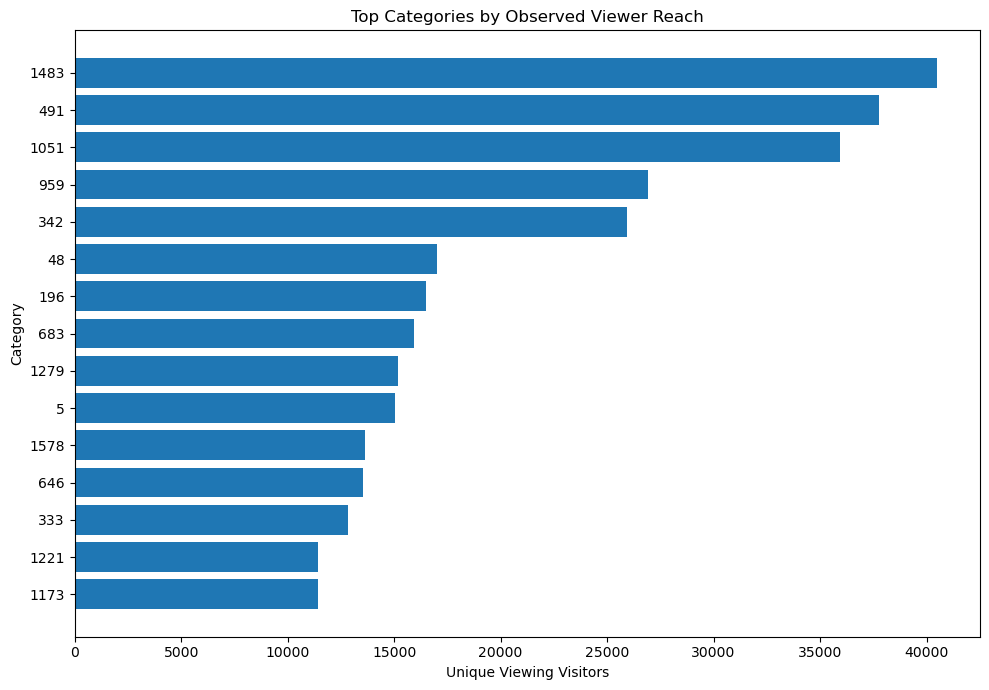

Saved figure: D:\Data science portfolio\03_Product_Growth_Intelligence\outputs\figures\07_top_categories_by_viewers.png


In [16]:
# ============================================================
# CELL 16 — CATEGORY REACH FIGURE
# ============================================================

plot_categories = (
    category_base[
        category_base["category"] != "Uncategorized"
    ]
    .sort_values("viewed_visitors", ascending=False)
    .head(15)
    .sort_values("viewed_visitors")
)

plt.figure(figsize=(10, 7))
plt.barh(
    plot_categories["category"].astype(str),
    plot_categories["viewed_visitors"],
)
plt.title("Top Categories by Observed Viewer Reach")
plt.xlabel("Unique Viewing Visitors")
plt.ylabel("Category")
plt.tight_layout()

category_reach_path = FIGURES_PATH / "07_top_categories_by_viewers.png"
plt.savefig(category_reach_path, dpi=250, bbox_inches="tight")
plt.show()

print("Saved figure:", category_reach_path)

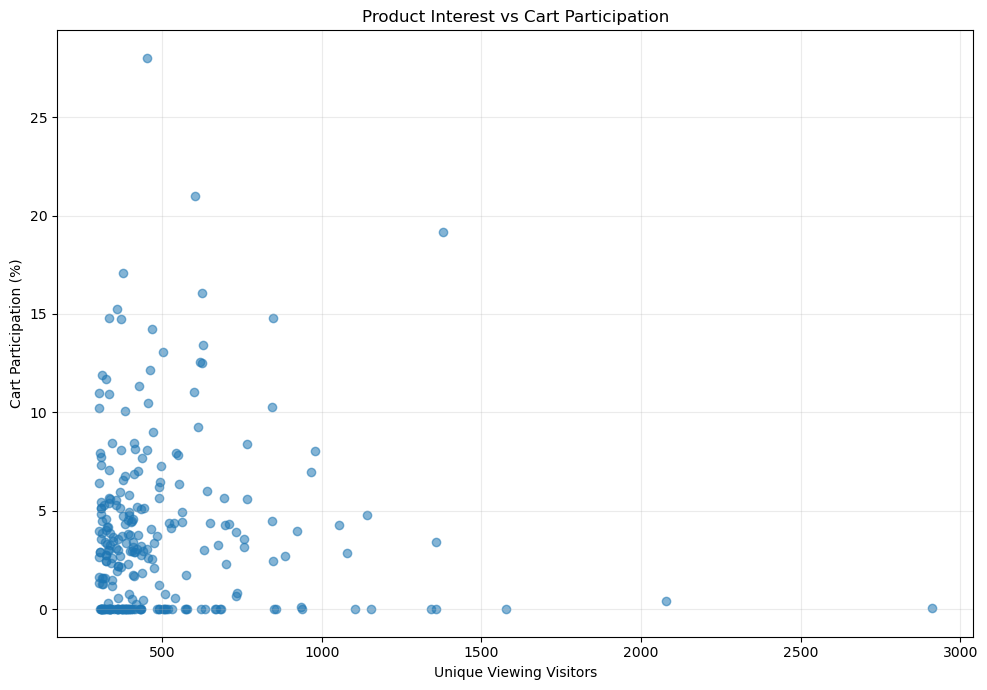

Saved figure: D:\Data science portfolio\03_Product_Growth_Intelligence\outputs\figures\07_product_interest_vs_cart_participation.png


In [17]:
# ============================================================
# CELL 17 — PRODUCT INTEREST VS CART PARTICIPATION
# ============================================================

plot_products = eligible_products[
    eligible_products["viewed_visitors"] >= product_interest_threshold
].copy()

plt.figure(figsize=(10, 7))
plt.scatter(
    plot_products["viewed_visitors"],
    plot_products["cart_participation_pct"],
    alpha=0.55,
)

plt.xlabel("Unique Viewing Visitors")
plt.ylabel("Cart Participation (%)")
plt.title("Product Interest vs Cart Participation")
plt.grid(alpha=0.25)
plt.tight_layout()

product_gap_path = FIGURES_PATH / "07_product_interest_vs_cart_participation.png"
plt.savefig(product_gap_path, dpi=250, bbox_inches="tight")
plt.show()

print("Saved figure:", product_gap_path)

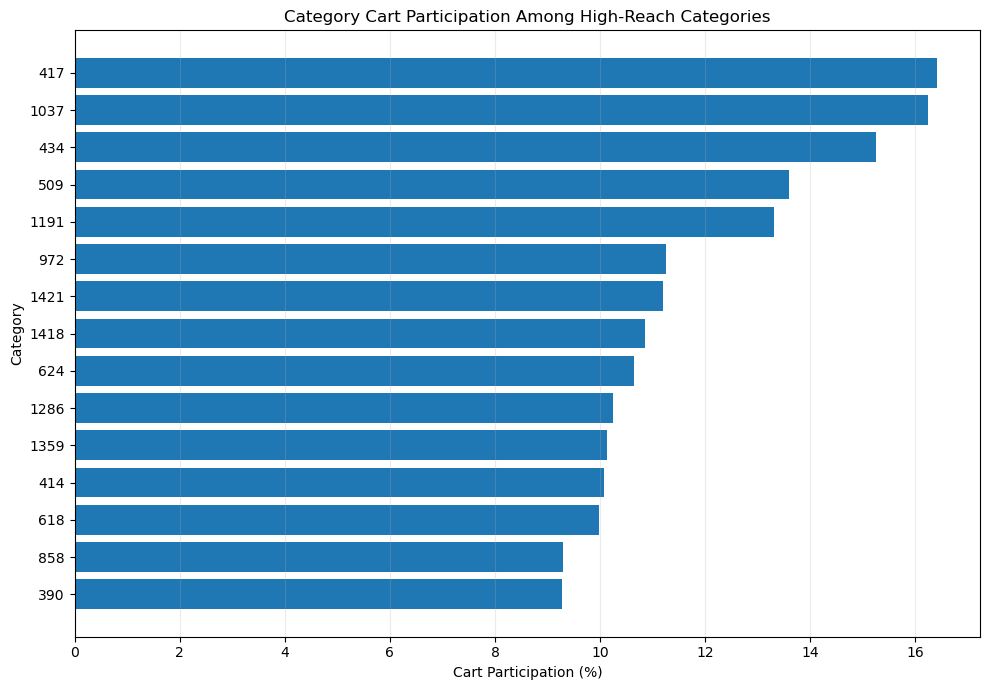

Saved figure: D:\Data science portfolio\03_Product_Growth_Intelligence\outputs\figures\07_category_cart_participation.png


In [18]:
# ============================================================
# CELL 18 — CATEGORY VIEW-TO-CART PARTICIPATION
# ============================================================

plot_category_conversion = (
    eligible_categories
    .sort_values("cart_participation_pct")
    .tail(15)
)

plt.figure(figsize=(10, 7))
plt.barh(
    plot_category_conversion["category"].astype(str),
    plot_category_conversion["cart_participation_pct"],
)

plt.xlabel("Cart Participation (%)")
plt.ylabel("Category")
plt.title("Category Cart Participation Among High-Reach Categories")
plt.grid(axis="x", alpha=0.25)
plt.tight_layout()

category_conversion_path = FIGURES_PATH / "07_category_cart_participation.png"
plt.savefig(category_conversion_path, dpi=250, bbox_inches="tight")
plt.show()

print("Saved figure:", category_conversion_path)

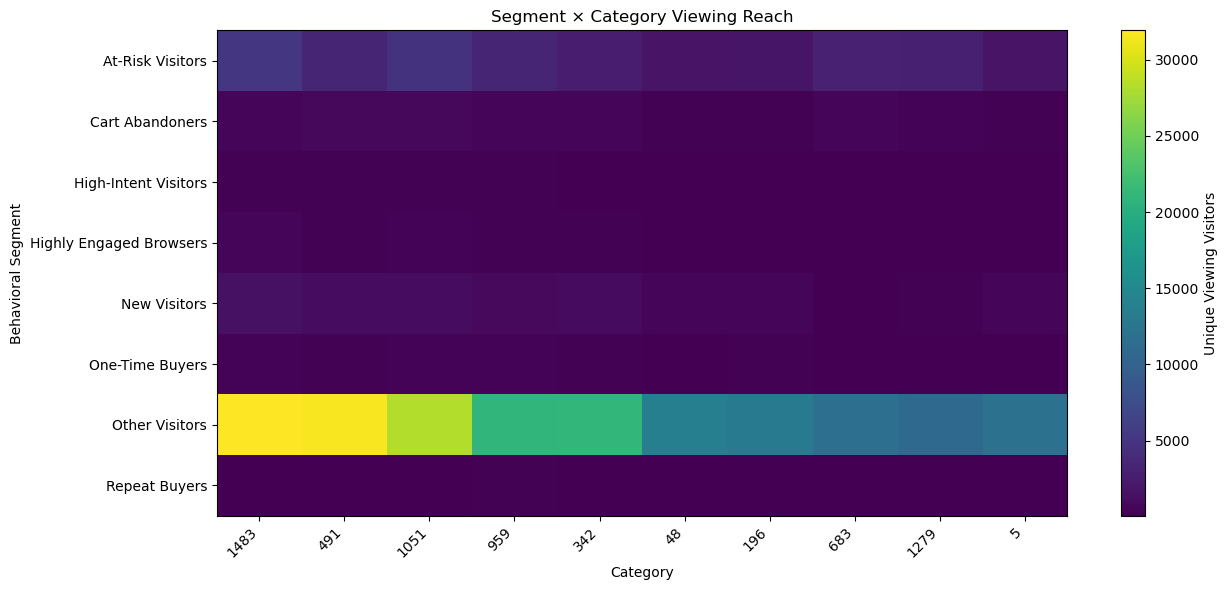

Saved figure: D:\Data science portfolio\03_Product_Growth_Intelligence\outputs\figures\07_segment_category_viewing_heatmap.png


In [19]:
# ============================================================
# CELL 19 — SEGMENT × CATEGORY ENGAGEMENT HEATMAP
# ============================================================

top_heatmap_categories = (
    events_segmented[
        events_segmented["event"].eq("view")
        & events_segmented["category_label"].ne("Uncategorized")
    ]
    .groupby("category_label")["visitorid"]
    .nunique()
    .sort_values(ascending=False)
    .head(10)
    .index
)

segment_category_heatmap = (
    events_segmented[
        events_segmented["category_label"].isin(top_heatmap_categories)
        & events_segmented["event"].eq("view")
    ]
    .groupby(["segment", "category_label"])["visitorid"]
    .nunique()
    .unstack(fill_value=0)
)

segment_category_heatmap = segment_category_heatmap.reindex(
    columns=top_heatmap_categories,
    fill_value=0,
)

plt.figure(figsize=(13, 6))
plt.imshow(segment_category_heatmap.values, aspect="auto")

plt.xticks(
    range(len(segment_category_heatmap.columns)),
    segment_category_heatmap.columns.astype(str),
    rotation=45,
    ha="right",
)
plt.yticks(
    range(len(segment_category_heatmap.index)),
    segment_category_heatmap.index,
)

plt.xlabel("Category")
plt.ylabel("Behavioral Segment")
plt.title("Segment × Category Viewing Reach")
plt.colorbar(label="Unique Viewing Visitors")
plt.tight_layout()

segment_category_path = FIGURES_PATH / "07_segment_category_viewing_heatmap.png"
plt.savefig(segment_category_path, dpi=250, bbox_inches="tight")
plt.show()

print("Saved figure:", segment_category_path)

## 9. Final Validation

The validation layer checks that:

- event coverage is preserved after enrichment
- item → category mapping has one current category per item
- Notebook 06 segments are unique per visitor
- product and category counts are non-negative
- participation rates remain within valid bounds
- exported opportunity tables contain only observed evidence
- required portfolio figures exist after generation

A failed validation raises an error so the notebook cannot silently be treated as final.

In [20]:
# ============================================================
# CELL 20 — FINAL VALIDATION CHECKS
# ============================================================

checks = {}

checks["event_population_reconciles"] = (
    len(events_product) == len(events)
)

checks["item_category_mapping_unique"] = (
    item_category["itemid"].is_unique
)

checks["segments_unique_per_visitor"] = (
    visitor_segments["visitorid"].is_unique
)

checks["product_counts_non_negative"] = (
    (product_base[
        [
            "visitors",
            "viewed_visitors",
            "cart_visitors",
            "transaction_visitors",
            "view_events",
            "cart_events",
            "transaction_events",
        ]
    ] >= 0).all().all()
)

checks["category_counts_non_negative"] = (
    (category_base[
        [
            "visitors",
            "viewed_visitors",
            "cart_visitors",
            "transaction_visitors",
            "view_events",
            "cart_events",
            "transaction_events",
        ]
    ] >= 0).all().all()
)

participation_columns = [
    "view_participation_pct",
    "cart_participation_pct",
    "transaction_participation_pct",
]

checks["product_participation_rates_valid"] = (
    product_base[participation_columns]
    .fillna(0)
    .apply(lambda col: col.between(0, 100))
    .all().all()
)

checks["category_participation_rates_valid"] = (
    category_base[participation_columns]
    .fillna(0)
    .apply(lambda col: col.between(0, 100))
    .all().all()
)

checks["figures_created"] = all(
    p.exists()
    for p in [
        category_reach_path,
        product_gap_path,
        category_conversion_path,
        segment_category_path,
    ]
)

print("FINAL VALIDATION")
print("=" * 70)

for check_name, passed in checks.items():
    print(
        f"{check_name.replace('_', ' ').title()}: "
        f"{'PASSED' if passed else 'FAILED'}"
    )

if not all(checks.values()):
    failed = [name for name, passed in checks.items() if not passed]
    raise AssertionError(
        "Validation failed: " + ", ".join(failed)
    )

print("\nALL PORTFOLIO VALIDATION CHECKS PASSED")

FINAL VALIDATION
Event Population Reconciles: PASSED
Item Category Mapping Unique: PASSED
Segments Unique Per Visitor: PASSED
Product Counts Non Negative: PASSED
Category Counts Non Negative: PASSED
Product Participation Rates Valid: PASSED
Category Participation Rates Valid: PASSED
Figures Created: PASSED

ALL PORTFOLIO VALIDATION CHECKS PASSED


## 10. Export Portfolio Outputs

These CSVs are designed as reusable analytical assets for the final Product & Growth Intelligence application.

### Product outputs

- product funnel profile
- top viewed products
- top cart-active products
- top purchased products
- high-interest / low-progression products

### Category outputs

- category funnel profile
- top viewed categories
- top cart-active categories
- top purchased categories
- high-interest / low-progression categories

### Cross-layer outputs

- segment × category intelligence
- item → category mapping
- category hierarchy mapping

In [21]:
# ============================================================
# CELL 21 — EXPORT PORTFOLIO OUTPUTS
# ============================================================

exports = {
    "07_product_intelligence.csv": product_base,
    "07_category_intelligence.csv": category_base,
    "07_product_opportunities.csv": product_opportunities,
    "07_category_opportunities.csv": category_opportunities,
    "07_top_viewed_products.csv": top_viewed_products,
    "07_top_cart_products.csv": top_cart_products,
    "07_top_purchased_products.csv": top_purchased_products,
    "07_top_viewed_categories.csv": top_viewed_categories,
    "07_top_cart_categories.csv": top_cart_categories,
    "07_top_purchased_categories.csv": top_purchased_categories,
    "07_segment_category_intelligence.csv": segment_category,
    "07_item_category_mapping.csv": item_category,
    "07_category_hierarchy.csv": category_root_df,
}

for file_name, frame in exports.items():
    frame.to_csv(OUTPUTS_PATH / file_name, index=False)

print("PORTFOLIO OUTPUTS EXPORTED")
print("=" * 70)

for file_name in exports:
    print(OUTPUTS_PATH / file_name)

print("\nFIGURES EXPORTED")
for path in [
    category_reach_path,
    product_gap_path,
    category_conversion_path,
    segment_category_path,
]:
    print(path)

PORTFOLIO OUTPUTS EXPORTED
D:\Data science portfolio\03_Product_Growth_Intelligence\outputs\07_product_intelligence.csv
D:\Data science portfolio\03_Product_Growth_Intelligence\outputs\07_category_intelligence.csv
D:\Data science portfolio\03_Product_Growth_Intelligence\outputs\07_product_opportunities.csv
D:\Data science portfolio\03_Product_Growth_Intelligence\outputs\07_category_opportunities.csv
D:\Data science portfolio\03_Product_Growth_Intelligence\outputs\07_top_viewed_products.csv
D:\Data science portfolio\03_Product_Growth_Intelligence\outputs\07_top_cart_products.csv
D:\Data science portfolio\03_Product_Growth_Intelligence\outputs\07_top_purchased_products.csv
D:\Data science portfolio\03_Product_Growth_Intelligence\outputs\07_top_viewed_categories.csv
D:\Data science portfolio\03_Product_Growth_Intelligence\outputs\07_top_cart_categories.csv
D:\Data science portfolio\03_Product_Growth_Intelligence\outputs\07_top_purchased_categories.csv
D:\Data science portfolio\03_Product_

# 11. Final Business Interpretation

## What this notebook establishes

The product/category layer connects visitor behavior to the objects the business can actually act on.

### Key analytical relationships

**Visitor → Event → Product → Category → Funnel**

### Decision-support questions answered

- Which products receive the greatest observed attention?
- Which products receive substantial attention but weaker cart participation?
- Which categories have the greatest observed visitor reach?
- Which categories show weaker purchase progression despite substantial interest?
- Which behavioral segments interact most with important categories?
- Where should the Growth Opportunity Engine investigate first?

### Important limitation

A high-interest / low-progression signal is a **diagnostic priority**, not proof of a product defect or causal explanation.

The dataset does not provide reliable revenue, profit, marketing source, demographics, randomized experiments, or guaranteed session boundaries. Therefore this notebook deliberately avoids those claims.

### Platform handoff

The analytical flow is now:

**Funnel → Retention → User Segments → Product & Category Intelligence → Growth Opportunity Engine → Streamlit Application**

Notebook 07 is therefore a reusable analytical layer, not merely a collection of charts.

---

## Notebook 07 — Final Portfolio Status

**Purpose:** Product & Category Intelligence.

**Method:** Event-based product/category funnel analysis with efficient item-property processing, transparent opportunity thresholds, and linkage to the finalized Notebook 06 visitor segments.

**Primary outputs:**

- product intelligence table
- category intelligence table
- product rankings
- category rankings
- high-interest / low-progression opportunities
- segment × category intelligence
- item → category mapping
- category hierarchy
- portfolio-ready figures
- validation checks
- reusable CSV exports

**Feeds next module:** Growth Opportunity Engine → Streamlit Application.

**Portfolio standard:** Run from a clean kernel using **Kernel → Restart Kernel and Run All**. After all validation checks pass, this notebook is locked for GitHub.